# A : Préparation des données



## A.1 : Librairies

In [311]:
##Indispensables
import os
import numpy as np
import pandas as pd

##Graphiques
import matplotlib.pyplot as plt
import seaborn as sns

##Projections
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.manifold import TSNE

##Métriques
from sklearn.metrics import silhouette_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import r2_score

##Modèles
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans

##Optimisation et export
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
import joblib

## A.2 : Fichier

In [312]:
df = pd.read_csv("billets.csv", sep=";")
display(df.head())

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [313]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


In [314]:
df['is_genuine'].value_counts()

,count
is_genuine,
True,1000
False,500


## A.3 : Valeurs manquantes

In [315]:
missing_data_percentage = df.isnull().sum() * 100 / len(df)
print("Pourcentage de données manquantes :")
display(round(missing_data_percentage[missing_data_percentage > 0],2))

Pourcentage de données manquantes :


,0
margin_low,2.47


Nous avons pour objectif d'extrapoler ces valeurs manquantes, mais pour l'instant nous allons les supprimer

In [316]:
df_trainimpute=df.copy()
df_trainimpute.dropna(inplace=True)

## A.3.1 : Prétraitement

Transformons les données brutes en données que les algorithmes de Machine Learning peuvent comprendre efficacement.

D'abord, séparons les variables explicatives et la cible :

X = les mesures du billet (longueur, hauteur, diagonales…)

y = l’étiquette (vrai ou faux)

In [317]:
X = df[['diagonal','height_right','height_left','margin_up','margin_low','length']]
y = df["is_genuine"]

Ensuite, séparons les données d'entraînement et les données test

In [318]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33,random_state=42)

## A.3.2 Validation de KNNImputer

On va sélectionner un sous-ensemble sans NaN, y créer de faux NaN, et comparer les valeurs prédites aux valeurs connues.

On itère cette méthode pour trouver nombre de voisins optimal pour KNNImputer.

In [319]:
##On copie X_train pour travailler proprement
X_train_clean_base = X_train.copy()
X_train_working = X_train_clean_base.copy()

##On cherche les indices où margin_low est non nul
non_null_margin_low_indices = X_train_clean_base[X_train_clean_base['margin_low'].notna()].index

##On sélectionne 20% de ces indices au hasard
indices_to_nan = non_null_margin_low_indices.to_series().sample(frac=0.2, random_state=42).index

##On sauvegarde les valeurs à ces indices pour comparer avec nos prédictions
original_values_for_evaluation = X_train_clean_base.loc[indices_to_nan, 'margin_low'].copy()

##On introduit des valeurs nulles à ces indices
X_train_working.loc[indices_to_nan, 'margin_low'] = np.nan

print(f"Nombre de NaN créés: {len(indices_to_nan)}")
print(f"Nombre de NaN dans 'margin_low' de X_train_working: {X_train_working['margin_low'].isnull().sum()}")
print(f"Nombre de NaN dans original_values_for_evaluation (cible=0): {original_values_for_evaluation.isnull().sum()}")

Nombre de NaN créés: 196
Nombre de NaN dans 'margin_low' de X_train_working: 223
Nombre de NaN dans original_values_for_evaluation (cible=0): 0


In [320]:
##On va maintenant mesurer la qualité de prédiction des valeurs
##manquantes créées pour pluisuers n-neighbors

imputation_results = []
k_values = range(2, 25)

for k in k_values:
    imputer = KNNImputer(n_neighbors=k)
    X_train_imputed_array_k = imputer.fit_transform(X_train_working)
    X_train_imputed_k = pd.DataFrame(X_train_imputed_array_k, columns=X_train_working.columns, index=X_train_working.index)
    imputed_for_missing_values_k = X_train_imputed_k.loc[indices_to_nan, 'margin_low']

    mae = mean_absolute_error(original_values_for_evaluation, imputed_for_missing_values_k)
    mse = mean_squared_error(original_values_for_evaluation, imputed_for_missing_values_k)
    rmse = np.sqrt(mse)
    r2 = r2_score(original_values_for_evaluation, imputed_for_missing_values_k)

    imputation_results.append({
        'n_neighbors': k,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

df_imputation_results = pd.DataFrame(imputation_results)
print("Evaluation de KNNImputer appliqué à 'margin_low' pour plusieurs n_neighbors:")
display(df_imputation_results.round(4))

Evaluation de KNNImputer appliqué à 'margin_low' pour plusieurs n_neighbors:


,n_neighbors,MAE,MSE,RMSE,R2
0,2,0.4071,0.3035,0.5509,0.3175
1,3,0.3973,0.2699,0.5195,0.3931
2,4,0.3770,0.2468,0.4968,0.4449
3,5,0.3765,0.2487,0.4987,0.4407
4,6,0.3817,0.2491,0.4991,0.4397
5,7,0.3619,0.2339,0.4837,0.4740
6,8,0.3615,0.2282,0.4777,0.4868
7,9,0.3570,0.2243,0.4736,0.4956
8,10,0.3508,0.2220,0.4712,0.5007
9,11,0.3535,0.2273,0.4768,0.4888


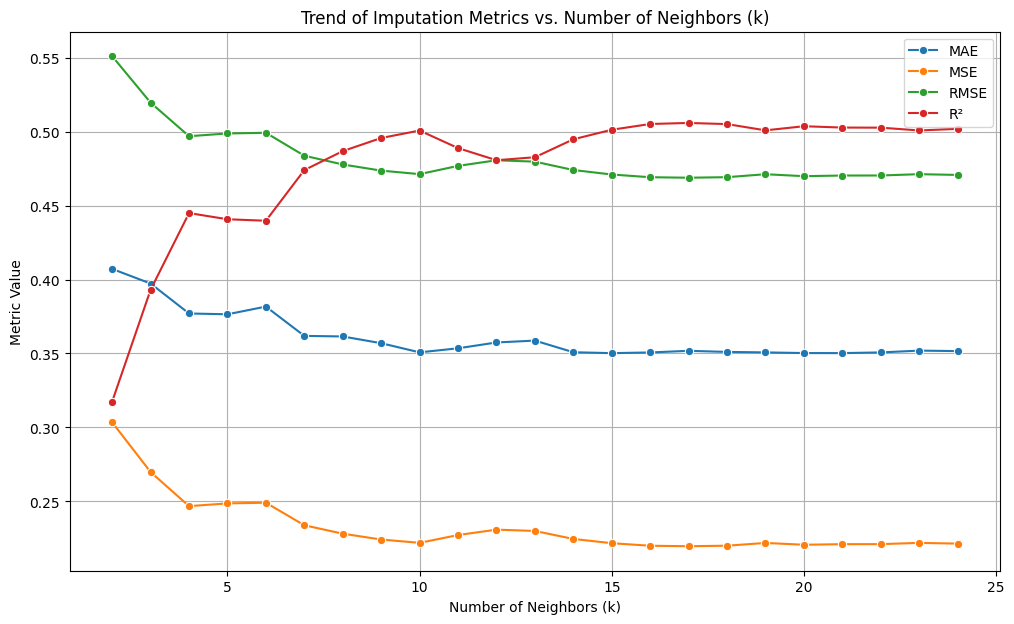

In [321]:
##Mettons ce tableau sous forme graphique
plt.figure(figsize=(12, 7))
sns.lineplot(x='n_neighbors', y='MAE', data=df_imputation_results, label='MAE', marker='o')
sns.lineplot(x='n_neighbors', y='MSE', data=df_imputation_results, label='MSE', marker='o')
sns.lineplot(x='n_neighbors', y='RMSE', data=df_imputation_results, label='RMSE', marker='o')
sns.lineplot(x='n_neighbors', y='R2', data=df_imputation_results, label='R²', marker='o')
plt.title('Trend of Imputation Metrics vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)
plt.show()

Après 10 voisins, l'augmentation du nombre de voisins entraîne une diminution moindre des métriques d'erreur (ou augmentation pour R²).

On va donc partir sur 10 voisins (avant le rebond).

## A.3.3 : Imputing

On peut maintenant utiliser KNNImputer avec 10 n-neighbors pour compléter nos données

In [322]:
imputer = KNNImputer(n_neighbors=10)
X_imputed_array = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed_array, columns=X.columns, index=X.index)

print("X_imputed DataFrame created successfully.")
display(X_imputed.head())
print("Missing values in df_imputed:")
display(X_imputed.isnull().sum())

X_imputed DataFrame created successfully.


,diagonal,height_right,height_left,margin_up,margin_low,length
0,171.81,104.95,104.86,2.89,4.52,112.83
1,171.46,103.66,103.36,2.99,3.77,113.09
2,172.69,103.50,104.48,2.94,4.40,113.16
3,171.36,103.94,103.91,3.01,3.62,113.51
4,171.73,103.46,104.28,3.48,4.04,112.54


Missing values in df_imputed:


,0
diagonal,0
height_right,0
height_left,0
margin_up,0
margin_low,0
length,0


On reprend le travail au début avec les données imputées

In [323]:
X = X_imputed
y = df["is_genuine"]

##Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

##Scaling
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# B : Analyse exploratoire (EDA)


In [324]:
df.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


## B.1 : Outliers

In [325]:
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


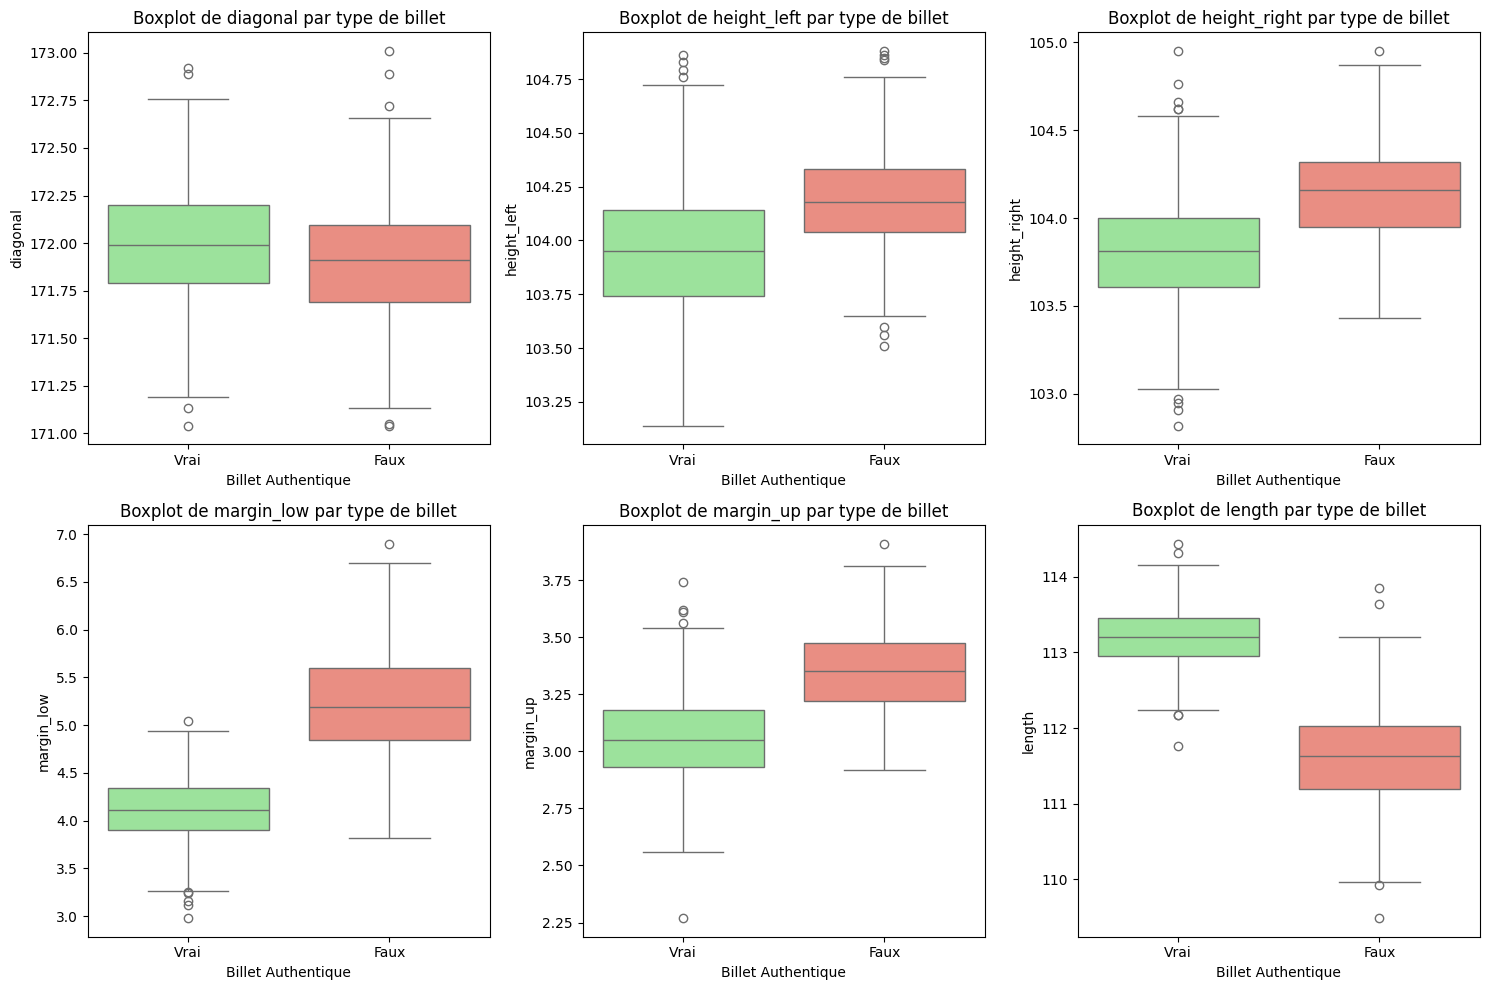

In [326]:
##On veut tracer les boxplots pour les variables quantitatives uniquement
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

##On crée une copie de travail de df en forçant is_genuine en tant que variable qualitative
df_plot = df.copy()
df_plot['is_genuine_label'] = df_plot['is_genuine'].map({True: 'Vrai', False: 'Faux'})

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) ##Ajuster la grille si plus de colonnes
    sns.boxplot(x='is_genuine_label', y=df_plot[col], data=df_plot, hue='is_genuine_label', palette={'Vrai': 'lightgreen', 'Faux': 'salmon'}, legend=False)
    plt.title(f'Boxplot de {col} par type de billet')
    plt.xlabel('Billet Authentique')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

## B.2 : Distribution

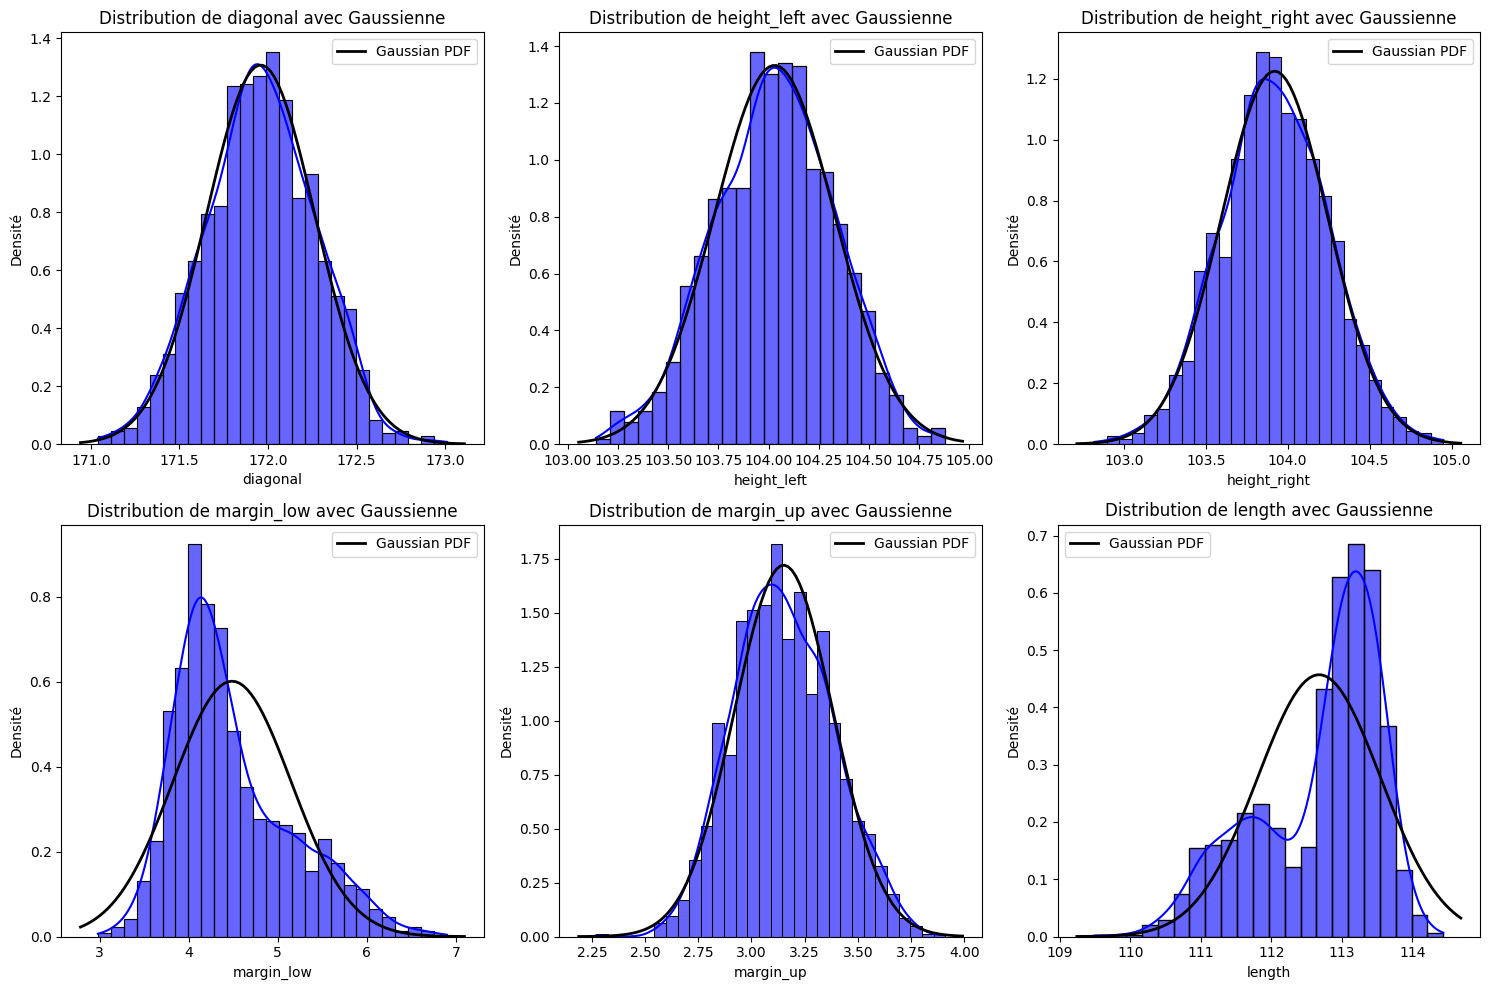

In [327]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)  # Ajuster la grille si plus de colonnes
    sns.histplot(df[col], kde=True, stat='density', alpha=0.6, color='blue')

    ##Calcul de la moyenne et de l'écart-type pour la colonne actuelle
    mu = df[col].mean()
    sigma = df[col].std()

    ##Affichage de la Gaussienne
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = (1/ (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)
    plt.plot(x, p, 'k', linewidth=2, label='Gaussian PDF')

    plt.title(f'Distribution de {col} avec Gaussienne')
    plt.xlabel(col)
    plt.ylabel('Densité')
    plt.legend()
plt.tight_layout()
plt.show()

## B.3 : Individu moyen

In [328]:
##Calculons les caratéristiques des individus moyens
df_moyenne = df.groupby('is_genuine').mean()

# Calcul de la différence en pourcentage entre True et False pour chaque colonne
percentage_difference = ((df_moyenne.loc[False] - df_moyenne.loc[True]) / df_moyenne.loc[True]) * 100
percentage_difference.name = "Pourcentage d'écart"
display(percentage_difference)

# Ajout de la ligne au DataFrame
df_moyenne = pd.concat([df_moyenne, pd.DataFrame([percentage_difference])])
display(df_moyenne)

,Pourcentage d'écart
diagonal,-0.049957
height_left,0.232046
height_right,0.322680
margin_low,26.720415
margin_up,9.764656
length,-1.388477


,diagonal,height_left,height_right,margin_low,margin_up,length
False,171.901160,104.190340,104.14362,5.215935,3.350160,111.630640
True,171.987080,103.949130,103.80865,4.116097,3.052130,113.202430
Pourcentage d'écart,-0.049957,0.232046,0.32268,26.720415,9.764656,-1.388477


## B.4 : PCA

In [329]:
##On scale, fit et transforme nos données
scaled_data=preprocessing.StandardScaler().fit_transform(X)

##On espère une moyenne à 0 et un écart type à 1
pd.DataFrame(scaled_data).describe().round(2).loc[['mean','std'], :]

,0,1,2,3,4,5
mean,-0.0,-0.0,0.0,-0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


In [330]:
##On instancie notre PCA
pca=PCA()

##On l'entraîne sur les données scalées
pca.fit(scaled_data)
pca_data=pca.transform(scaled_data)

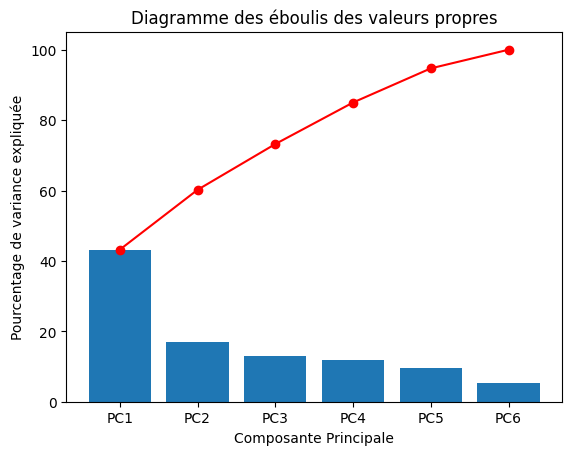

In [331]:
##On calcule les pourcentages de variance expliquée
per_var=np.round(pca.explained_variance_ratio_*100,decimals=1)

##On calcule également les sommes cumulées de nos variances expliquées
scree_cum=np.cumsum(per_var)

##On crée une liste d'étiquettes avec les noms de nos composantes principales
labels=['PC'+str(x) for x in range (1, len(per_var)+1)]

##On affiche tout cela graphiquement
plt.bar(x=range(1,len(per_var)+1),height=per_var,tick_label=labels)
plt.plot(range(1,len(per_var)+1), scree_cum,c="red",marker='o')
plt.ylabel('Pourcentage de variance expliquée')
plt.xlabel('Composante Principale')
plt.title('Diagramme des éboulis des valeurs propres')
plt.show()

In [332]:
##On enregistre notre nouvelle base
X_proj = pca.transform(scaled_data)
X_proj[:4]

array([[-1.64780343,  0.74975876,  2.38368373,  3.18950702,  0.33458809,
        -0.02226288],
       [ 2.02008373, -2.2074739 , -1.00069304,  0.06704924,  0.0455343 ,
        -0.48069714],
       [ 0.97218608,  2.61825002,  1.20188639, -0.90751083, -0.8517669 ,
         0.20202403],
       [ 1.37582723, -1.81597756,  0.64666527,  0.82469683,  0.81721163,
        -0.23153189]])

In [333]:
##Fonction pour le graphique, à appeler pour chaque plan

def display_factorial_planes(   X_projected,
                                x_y,
                                pca=None,
                                labels = None,
                                clusters=None,
                                alpha=1,
                                figsize=[10,8],
                                color=None,
                                marker=".",
                                palette=None ):

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize:
        figsize = (7,6)

    # On gère les labels
    if  labels is None :
        labels = []
    try :
        len(labels)
    except Exception as e :
        raise e

    # On vérifie la variable axis
    if not len(x_y) ==2 :
        raise AttributeError("2 axes sont demandées")
    if max(x_y )>= X_.shape[1] :
        raise AttributeError("la variable axis n'est pas bonne")

    # on définit x et y
    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters

    # Les points
    # plt.scatter(   X_[:, x], X_[:, y], alpha=alpha,
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c, palette=palette)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe
    if pca :
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else :
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'PC{x+1} {v1}')
    ax.set_ylabel(f'PC{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) :
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center')

    # Titre et display
    plt.title(f"Projection des individus (sur PC{x+1} et PC{y+1})")
    plt.show()

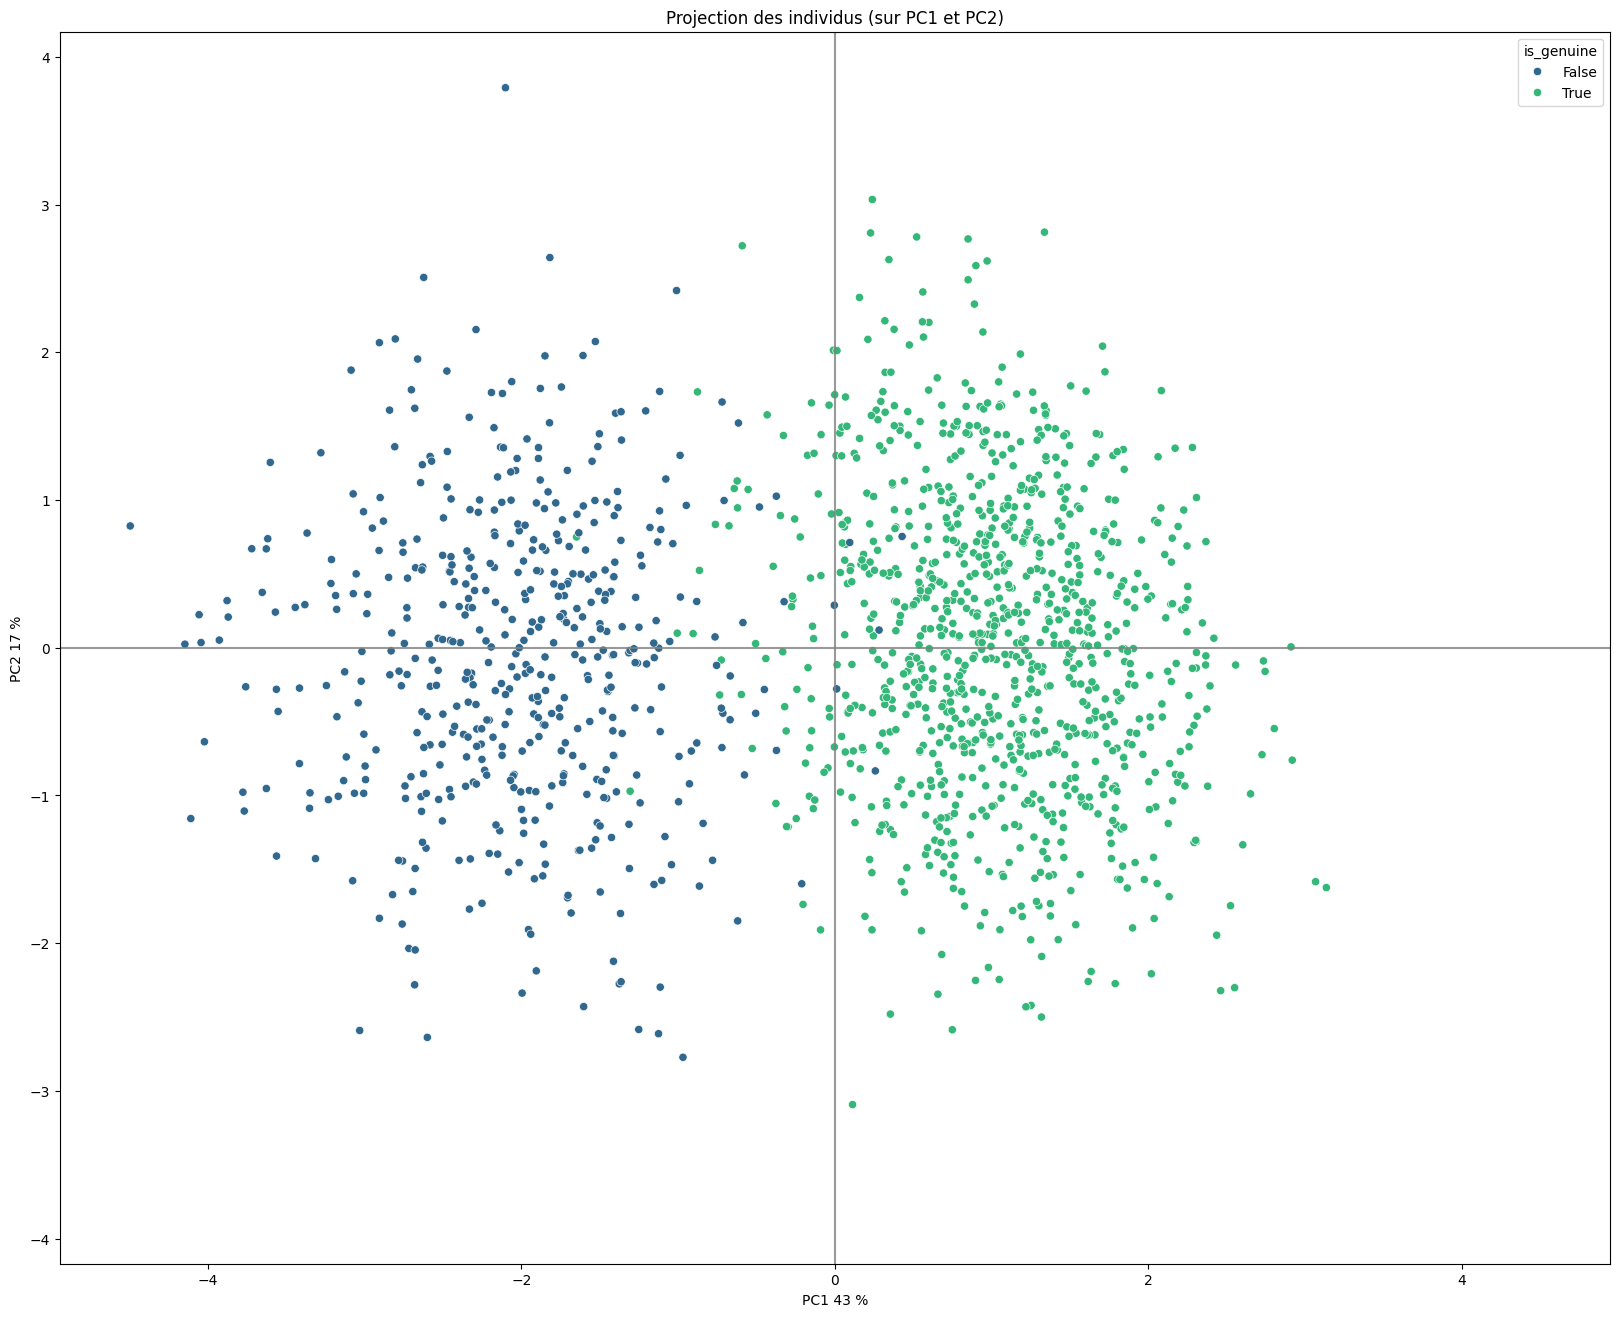

In [334]:
#Graphique pour (PC1,PC2)
x_y = [0,1]
display_factorial_planes(X_proj, x_y, pca, figsize=(20,16),clusters=df['is_genuine'], marker="o",palette='viridis')

# C : Modélisation

## C.1 : KMeans

KMeans est un algorithme de clustering et non de classification, on va quand même le tester sur nos données

Vérifions le nombre de clusters à fournir à KMeans

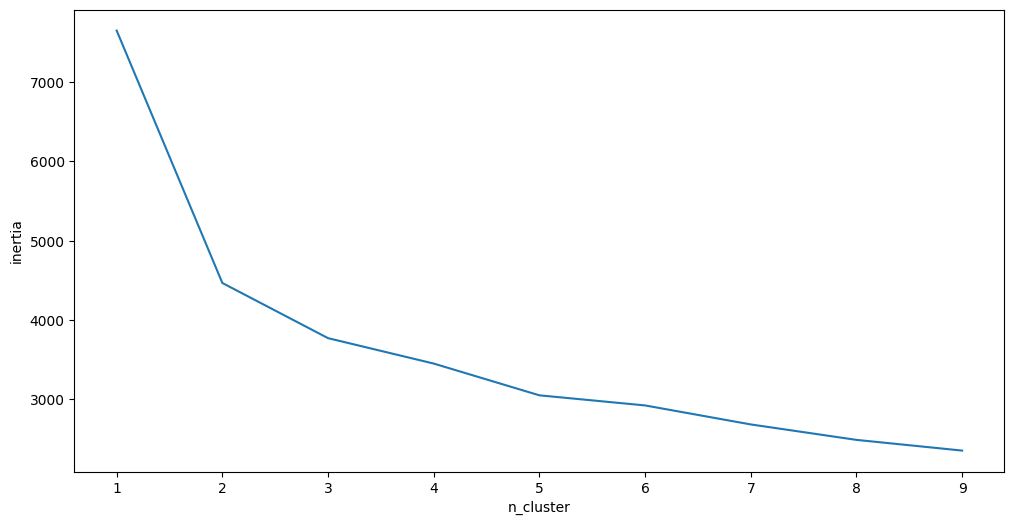

In [335]:
##On calcule les inerties pour identifier un nombre pertinent de clusters

# Une liste vide pour enregistrer les inerties :
inertia_list = [ ]

# Notre liste de nombres de clusters :
k_list = range(1, 10)

# Pour chaque nombre de clusters :
for k in k_list :

    # On instancie un k-means pour k clusters
    kmeans = KMeans(n_clusters=k,random_state=42)

    # On entraine
    kmeans.fit(X_proj[:,:4])

    # On enregistre l'inertie obtenue :
    inertia_list.append(kmeans.inertia_)

##On affiche le résultat
fig, ax = plt.subplots(1,1,figsize=(12,6))

ax.set_ylabel("inertia")
ax.set_xlabel("n_cluster")
ax = plt.plot(k_list, inertia_list)

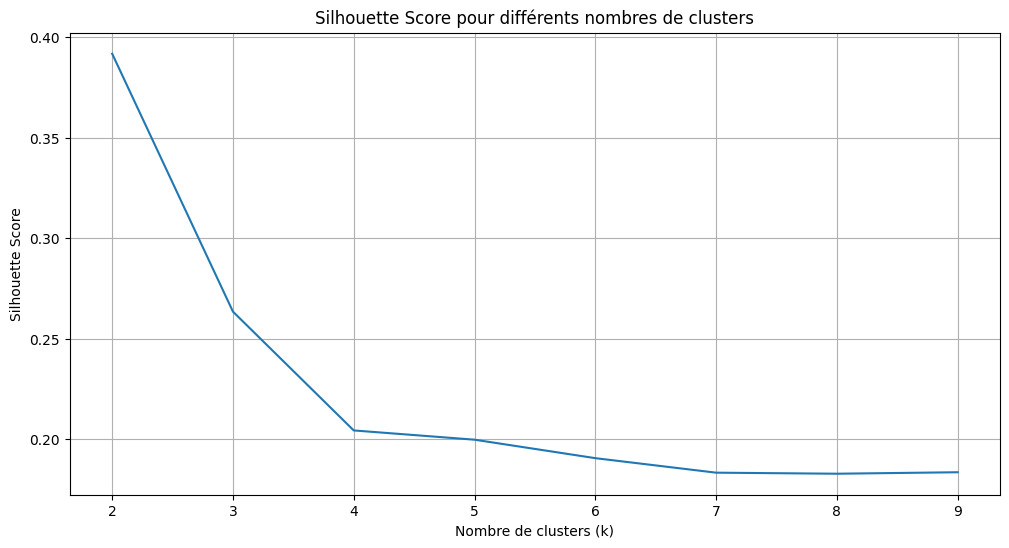

In [336]:
##On va tracer le silhouette score pour valider le nombre de clusters

silhouette_scores = []

# Pour chaque nombre de clusters (en commençant par 2) :
for i in range(2, 10):
    # On instancie un k-means pour i clusters
    km = KMeans(n_clusters=i, random_state=42)

    # On entraine et on prédit
    km.fit_predict(X_proj[:,:4])

    # On enregistre le score de silhouette obtenu :
    silhouette_scores.append(silhouette_score(X_proj[:,:4], km.labels_, metric='euclidean'))


##On affiche le résultat
fig, ax = plt.subplots(1,1,figsize=(12,6))
ax.set_ylabel("Silhouette Score")
ax.set_xlabel("Nombre de clusters (k)")
ax.plot(k_list[1:], silhouette_scores)
plt.title('Silhouette Score pour différents nombres de clusters')
plt.grid(True)
plt.show()


Nombre de clusters optimal : 2

C'est cohérent avec la nature de nos données

In [337]:
##On peut maintenant lancer notre KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train_scaled,y_train)
y_pred_kmeans = kmeans.predict(X_test_scaled)

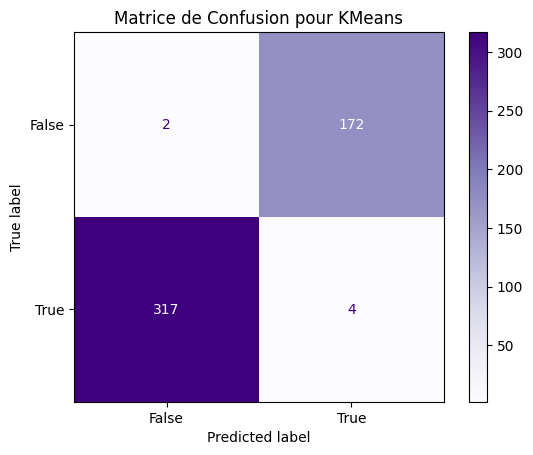

In [338]:
##Calcul de la matrice de confusion pour KMeans
##Nous retirons 'labels=kmeans.classes_' car KMeans n'a pas cet attribut.
##Les labels pourraient donc ne pas correspondre
cm_kmeans = confusion_matrix(y_test, y_pred_kmeans)

##Affichage de la matrice de confusion pour KMeans
disp_kmeans = ConfusionMatrixDisplay(confusion_matrix=cm_kmeans, display_labels=[False, True])
disp_kmeans.plot(cmap=plt.cm.Purples)
plt.title('Matrice de Confusion pour KMeans')
plt.show()

K-Means est non supervisé, il n'a pas la notion de classes.

Ici il a inversé la signification de nos données, nous allons devoir réaligner les étiquettes manuellement

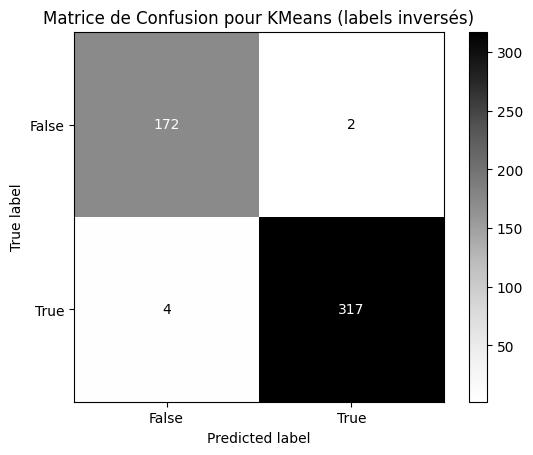

In [339]:
##Ré-alignons les étiquettes
y_pred_kmeans_inverted = 1 - y_pred_kmeans

##Nouvelle matrice de confusion
cm_kmeans_inverted = confusion_matrix(y_test, y_pred_kmeans_inverted, labels=[False, True])
disp_kmeans_inverted = ConfusionMatrixDisplay(confusion_matrix=cm_kmeans_inverted, display_labels=[False, True])
disp_kmeans_inverted.plot(cmap=plt.cm.Greys)
plt.title('Matrice de Confusion pour KMeans (labels inversés)')
plt.show()

In [340]:
##Evaluons l'efficacité de K-Means
accuracy_kmeans = accuracy_score(y_test, y_pred_kmeans_inverted)
print(f'Accuracy du classifieur K-Means (labels inversés) : {accuracy_kmeans}')

precision_score_kmeans = precision_score(y_test, y_pred_kmeans_inverted)
print(f'Precision du classifieur K-Means (labels inversés) : {precision_score_kmeans}')

recall_score_kmeans = recall_score(y_test, y_pred_kmeans_inverted)
print(f'Recall du classifieur K-Means (labels inversés) : {recall_score_kmeans}')

f1_score_kmeans = f1_score(y_test, y_pred_kmeans_inverted)
print(f'F1 score du classifieur K-Means (labels inversés) : {f1_score_kmeans}')

roc_auc_score_kmeans = roc_auc_score(y_test, y_pred_kmeans_inverted)
print(f'ROC-AUC score du classifieur K-Means (labels inversés) : {roc_auc_score_kmeans}')

classification_report_kmeans = classification_report(y_test, y_pred_kmeans_inverted)
print('\nClassification Report pour le classifieur K-Means (labels inversés):\n')
print(classification_report_kmeans)


Accuracy du classifieur K-Means (labels inversés) : 0.9878787878787879
Precision du classifieur K-Means (labels inversés) : 0.9937304075235109
Recall du classifieur K-Means (labels inversés) : 0.9875389408099688
F1 score du classifieur K-Means (labels inversés) : 0.990625
ROC-AUC score du classifieur K-Means (labels inversés) : 0.9880223439682028

Classification Report pour le classifieur K-Means (labels inversés):

              precision    recall  f1-score   support

       False       0.98      0.99      0.98       174
        True       0.99      0.99      0.99       321

    accuracy                           0.99       495
   macro avg       0.99      0.99      0.99       495
weighted avg       0.99      0.99      0.99       495



Visualisons nos données grâce à la méthode T-SNE, une projection non-linéaire cherchant à conserver les relations pair à pair entre les individus

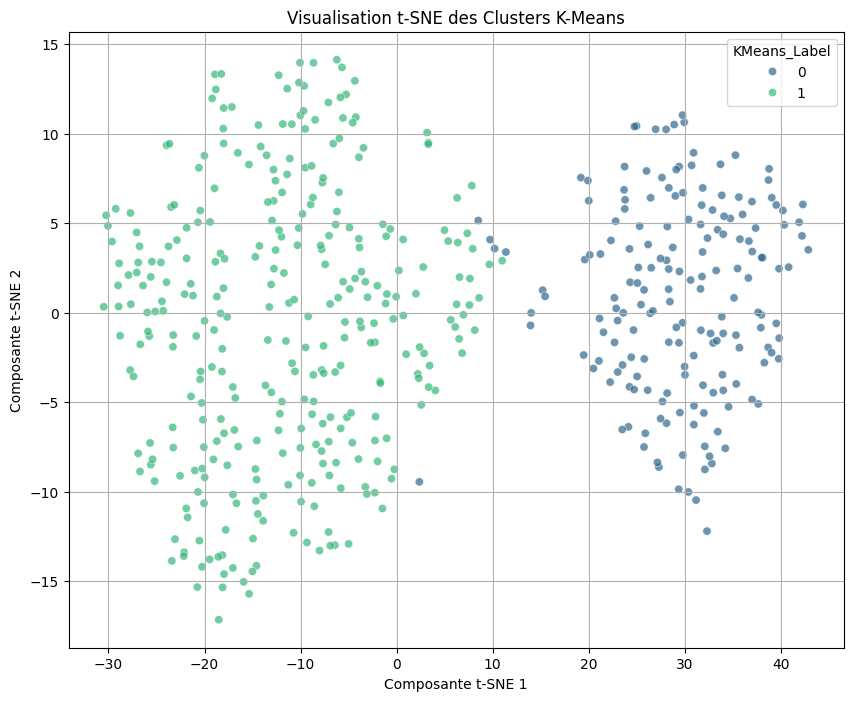

In [341]:
##Appliquer t-SNE sur les données test scalées
tsne = TSNE(n_components=2, random_state=42)
X_test_tsne = tsne.fit_transform(X_test_scaled)

##Créer un DataFrame pour la visualisation
tsne_df = pd.DataFrame(data = X_test_tsne, columns = ['TSNE_Component_1', 'TSNE_Component_2'])
tsne_df['KMeans_Label'] = y_pred_kmeans_inverted.astype(str)

##Visualisation des clusters K-Means avec t-SNE
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE_Component_1', y='TSNE_Component_2', hue='KMeans_Label', palette='viridis', data=tsne_df, legend='full', alpha=0.7
)
plt.title('Visualisation t-SNE des Clusters K-Means')
plt.xlabel('Composante t-SNE 1')
plt.ylabel('Composante t-SNE 2')
plt.grid(True)
plt.show()

## C.2 : Logistic Regression

In [342]:
##Testons maintenant la régression logistique
logreg=LogisticRegression(max_iter=100,random_state=42)
logreg.fit(X_train_scaled,y_train)
y_pred_logreg=logreg.predict(X_test_scaled)

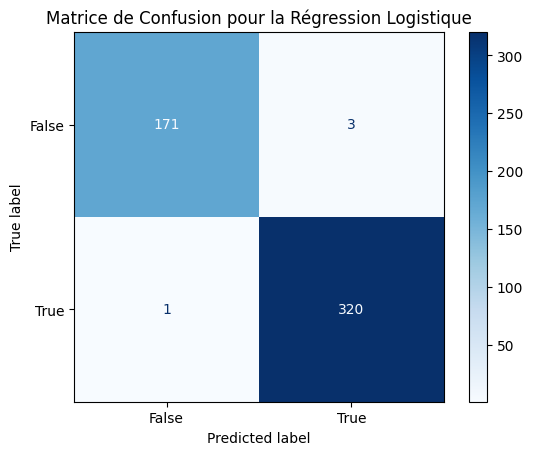

In [343]:
##Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred_logreg, labels=logreg.classes_)

##Affichage de la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matrice de Confusion pour la Régression Logistique')
plt.show()

In [344]:
accuracy_logreg=accuracy_score(y_test, y_pred_logreg)
print(f'Accuracy de la régression logistique : {accuracy_logreg}')

precision_score_logreg=precision_score(y_test, y_pred_logreg)
print(f'Precision de la régression logistique : {precision_score_logreg}')

recall_score_logreg=recall_score(y_test, y_pred_logreg)
print(f'Recall de la régression logistique : {recall_score_logreg}')

f1_score_logreg=f1_score(y_test, y_pred_logreg)
print(f'F1 score de la régression logistique : {f1_score_logreg}')

roc_auc_score_logreg=roc_auc_score(y_test, y_pred_logreg)
print(f'ROC-AUC score de la régression logistique : {roc_auc_score_logreg}')

classification_report_logreg=classification_report(y_test, y_pred_logreg)
print(classification_report_logreg)

Accuracy de la régression logistique : 0.9919191919191919
Precision de la régression logistique : 0.9907120743034056
Recall de la régression logistique : 0.9968847352024922
F1 score de la régression logistique : 0.9937888198757764
ROC-AUC score de la régression logistique : 0.9898216779460738
              precision    recall  f1-score   support

       False       0.99      0.98      0.99       174
        True       0.99      1.00      0.99       321

    accuracy                           0.99       495
   macro avg       0.99      0.99      0.99       495
weighted avg       0.99      0.99      0.99       495



## C.3 : K-Neighbors

In [345]:
##Testons le classifieur KNN avec n_neighbors=10 (cf A.3.2 : Validation de KNNImputer)
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

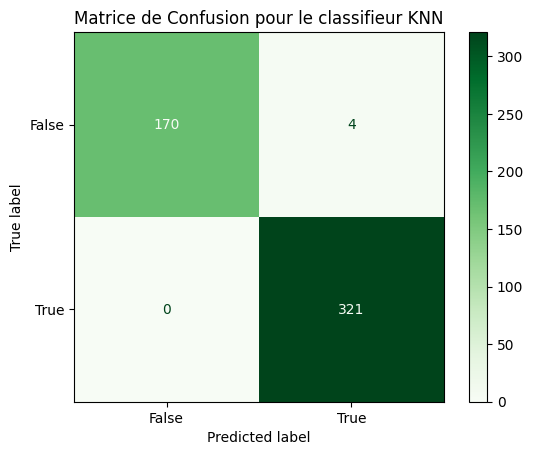

In [346]:
##Calcul de la matrice de confusion pour KNN
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=knn.classes_)

##Affichage de la matrice de confusion pour KNN
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn.classes_)
disp_knn.plot(cmap=plt.cm.Greens)
plt.title('Matrice de Confusion pour le classifieur KNN')
plt.show()

In [347]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f'Accuracy du classifieur KNN : {accuracy_knn}')

precision_score_knn = precision_score(y_test, y_pred_knn)
print(f'Precision du classifieur KNN : {precision_score_knn}')

recall_score_knn = recall_score(y_test, y_pred_knn)
print(f'Recall du classifieur KNN : {recall_score_knn}')

f1_score_knn = f1_score(y_test, y_pred_knn)
print(f'F1 score du classifieur KNN : {f1_score_knn}')

roc_auc_score_knn = roc_auc_score(y_test, y_pred_knn)
print(f'ROC-AUC score du classifieur KNN : {roc_auc_score_knn}')

classification_report_knn = classification_report(y_test, y_pred_knn)
print('\nClassification Report pour le classifieur KNN:\n')
print(classification_report_knn)

Accuracy du classifieur KNN : 0.9919191919191919
Precision du classifieur KNN : 0.9876923076923076
Recall du classifieur KNN : 1.0
F1 score du classifieur KNN : 0.9938080495356038
ROC-AUC score du classifieur KNN : 0.9885057471264368

Classification Report pour le classifieur KNN:

              precision    recall  f1-score   support

       False       1.00      0.98      0.99       174
        True       0.99      1.00      0.99       321

    accuracy                           0.99       495
   macro avg       0.99      0.99      0.99       495
weighted avg       0.99      0.99      0.99       495



## C.4 : Random Forest Classifier

In [348]:
##On passe maintenant au classifieur Random Forest
rfc = RandomForestClassifier(n_estimators=100,random_state=42)
rfc.fit(X_train_scaled, y_train)
y_pred_rfc = rfc.predict(X_test_scaled)

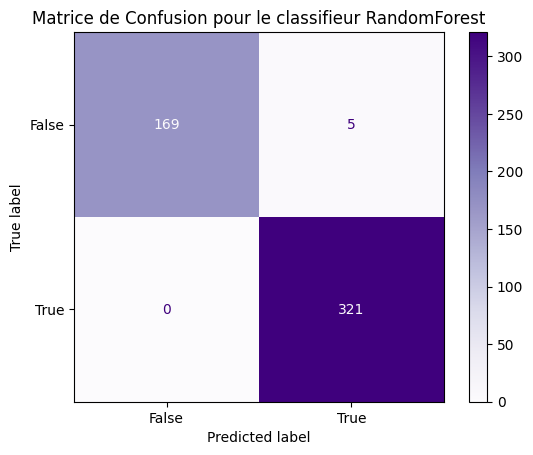

In [349]:
##Calcul de la matrice de confusion pour RandomForestClassifier
cm_rfc = confusion_matrix(y_test, y_pred_rfc, labels=rfc.classes_)

##Affichage de la matrice de confusion pour RandomForestClassifier
disp_rfc = ConfusionMatrixDisplay(confusion_matrix=cm_rfc, display_labels=rfc.classes_)
disp_rfc.plot(cmap=plt.cm.Purples)
plt.title('Matrice de Confusion pour le classifieur RandomForest')
plt.show()

In [350]:
accuracy_rfc = accuracy_score(y_test, y_pred_rfc)
print(f'Accuracy du classifieur Random Forest : {accuracy_rfc}')

precision_score_rfc = precision_score(y_test, y_pred_rfc)
print(f'Precision du classifieur Random Forest : {precision_score_rfc}')

recall_score_rfc = recall_score(y_test, y_pred_rfc)
print(f'Recall du classifieur Random Forest : {recall_score_rfc}')

f1_score_rfc = f1_score(y_test, y_pred_rfc)
print(f'F1 score du classifieur Random Forest : {f1_score_rfc}')

roc_auc_score_rfc = roc_auc_score(y_test, y_pred_rfc)
print(f'ROC-AUC score du classifieur Random Forest : {roc_auc_score_rfc}')

classification_report_rfc = classification_report(y_test, y_pred_rfc)
print('\nClassification Report pour le classifieur Random Forest:\n')
print(classification_report_rfc)

Accuracy du classifieur Random Forest : 0.98989898989899
Precision du classifieur Random Forest : 0.9846625766871165
Recall du classifieur Random Forest : 1.0
F1 score du classifieur Random Forest : 0.9922720247295209
ROC-AUC score du classifieur Random Forest : 0.985632183908046

Classification Report pour le classifieur Random Forest:

              precision    recall  f1-score   support

       False       1.00      0.97      0.99       174
        True       0.98      1.00      0.99       321

    accuracy                           0.99       495
   macro avg       0.99      0.99      0.99       495
weighted avg       0.99      0.99      0.99       495



# D : Sélection du meilleur modèle



## D.1 : Benchmark

In [351]:
##On va comparer les métriques d'évaluation pour nos différents modèles
data = {
    'Model': ['Logistic Regression', 'K-Neighbors', 'Random Forest', 'K-Means (mapped labels)'],
    'Accuracy': [accuracy_logreg, accuracy_knn, accuracy_rfc, accuracy_kmeans],
    'Precision': [precision_score_logreg, precision_score_knn, precision_score_rfc, precision_score_kmeans],
    'Recall': [recall_score_logreg, recall_score_knn, recall_score_rfc, recall_score_kmeans],
    'F1-Score': [f1_score_logreg, f1_score_knn, f1_score_rfc, f1_score_kmeans],
    'ROC-AUC': [roc_auc_score_logreg, roc_auc_score_knn, roc_auc_score_rfc, roc_auc_score_kmeans]
}

df_results = pd.DataFrame(data)
display(df_results.round(4))


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9919,0.9907,0.9969,0.9938,0.9898
1,K-Neighbors,0.9919,0.9877,1.0000,0.9938,0.9885
2,Random Forest,0.9899,0.9847,1.0000,0.9923,0.9856
3,K-Means (mapped labels),0.9879,0.9937,0.9875,0.9906,0.9880


La priorité est de limiter le nombre de faux billets non-identifiés en circulation (haut precision_score), et ensuite de limiter le nombre de billets authentiques identifiés comme faux (haut recall_score).

Au vu de métrique, la régression logistique semble être le modèle le plus adapté à nos données et à nos objectifs.
Nous allons maintenant chercher à améliorer ce modèle.

## D.2 : Amélioration de la régression logistique

Nous allons utiliser la fonction GridSearchCV, qui va effctuer des régression logistiques avec différents hyper-paramètres, afin d'identifier la meilleure configuration.

Fitting 5 folds for each of 21 candidates, totalling 105 fits
Meilleurs paramètres pour la régression logistique : {'logisticregression__C': 0.01, 'logisticregression__solver': 'liblinear'}
Meilleur score de validation croisée (accuracy) : 0.9881

Accuracy de la régression logistique améliorée : 0.9919
Precision de la régression logistique améliorée : 0.9938
Recall de la régression logistique améliorée : 0.9938
F1 score de la régression logistique améliorée : 0.9938
ROC-AUC score de la régression logistique améliorée : 0.9911

Classification Report pour la régression logistique améliorée :
              precision    recall  f1-score   support

       False       0.99      0.99      0.99       174
        True       0.99      0.99      0.99       321

    accuracy                           0.99       495
   macro avg       0.99      0.99      0.99       495
weighted avg       0.99      0.99      0.99       495



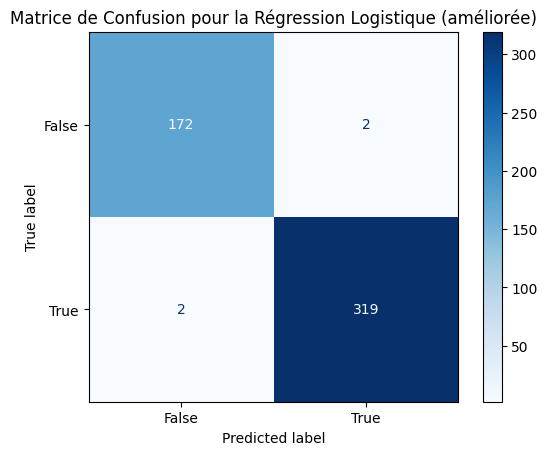

In [352]:
##Créer un pipeline avec le StandardScaler et la régression logistique en utilisant make_pipeline
pipeline_logreg = make_pipeline(
    preprocessing.StandardScaler(),
    LogisticRegression(random_state=42, max_iter=1000) # Augmenter max_iter si la convergence est un problème
)

##Définir la grille de paramètres à tester (ajusté pour make_pipeline)
param_grid_logreg = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'logisticregression__solver': ['liblinear', 'lbfgs', 'saga']
}

##Initialiser GridSearchCV
grid_search_logreg = GridSearchCV(pipeline_logreg, param_grid_logreg, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
##En toute logique on devrait utiliser scoring="precision", mais cela donné un moins bon résultat

##Entraîner GridSearchCV sur les données d'entraînement
grid_search_logreg.fit(X_train, y_train)

##Afficher les meilleurs paramètres et le meilleur score
print(f"Meilleurs paramètres pour la régression logistique : {grid_search_logreg.best_params_}")
print(f"Meilleur score de validation croisée (accuracy) : {grid_search_logreg.best_score_:.4f}")

##Obtenir le meilleur modèle
best_logreg_model = grid_search_logreg.best_estimator_

##Prédire sur l'ensemble de test avec le meilleur modèle
y_pred_logreg_tuned = best_logreg_model.predict(X_test)

##Calculer et afficher les métriques du modèle amélioré
accuracy_logreg_tuned = accuracy_score(y_test, y_pred_logreg_tuned)
precision_logreg_tuned = precision_score(y_test, y_pred_logreg_tuned)
recall_logreg_tuned = recall_score(y_test, y_pred_logreg_tuned)
f1_score_logreg_tuned = f1_score(y_test, y_pred_logreg_tuned)
roc_auc_score_logreg_tuned = roc_auc_score(y_test, y_pred_logreg_tuned)

print(f'\nAccuracy de la régression logistique améliorée : {accuracy_logreg_tuned:.4f}')
print(f'Precision de la régression logistique améliorée : {precision_logreg_tuned:.4f}')
print(f'Recall de la régression logistique améliorée : {recall_logreg_tuned:.4f}')
print(f'F1 score de la régression logistique améliorée : {f1_score_logreg_tuned:.4f}')
print(f'ROC-AUC score de la régression logistique améliorée : {roc_auc_score_logreg_tuned:.4f}')

print('\nClassification Report pour la régression logistique améliorée :')
print(classification_report(y_test, y_pred_logreg_tuned))

##Calcul et affichage de la matrice de confusion
cm_tuned = confusion_matrix(y_test, y_pred_logreg_tuned, labels=best_logreg_model.classes_)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=best_logreg_model.classes_)
disp_tuned.plot(cmap=plt.cm.Blues)
plt.title('Matrice de Confusion pour la Régression Logistique (améliorée)')
plt.show()

## D.3 : Sauvegarde du meilleur modèle

**_ATTENTION_** :
```
Sauvegarder un modèle implique de sauvegarder aussi les étapes de préprocessing des données.
Dans votre cas, vous devez donc inclure, à minima, votre StandardScaler.
```
Voir [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) pour plus d'infos.

In [353]:
from sklearn.pipeline import make_pipeline
import joblib

##Pour utiliser GridSearchCV, nous avons dû utilser make_pipeline
##pour inclure toutes les étapes nécessaires
##à la prédiction de si un billet est vrai ou faux.

##On sauvegarde notre modèle amélioré identifié grâce à GridSearchCV
##à l'aide de la librairie joblib.
joblib.dump(best_logreg_model, 'best_logistic_regression_model.joblib')
print("Modèle logistique optimisé sauvegardé sous 'best_logistic_regression_model.joblib'")

Modèle logistique optimisé sauvegardé sous 'best_logistic_regression_model.joblib'


##D.4 : Test production

On va tester notre modèle sur d'autres données

In [354]:
df_prod=pd.read_csv('billets_production.csv')

In [355]:
##Charger le modèle sauvegardé
best_logreg_model = joblib.load('best_logistic_regression_model.joblib')

##Séparer l'ID des caractéristiques
df_prod_ids = df_prod['id']
X_prod = df_prod.drop(columns=['id'])

##Assurez-vous que l'ordre des colonnes de X_prod correspond à celui utilisé lors de l'entraînement
##X est le DataFrame global de formation après imputation et avant le split train/test
X_prod = X_prod[X.columns]

##Appliquer le modèle aux données de production (le pipeline gérera la mise à l'échelle)
y_pred_prod = best_logreg_model.predict(X_prod)

##Créer un DataFrame de résultats
df_predictions = pd.DataFrame({'id': df_prod_ids, 'is_genuine_predicted': y_pred_prod})

print("Prédictions pour les billets de production :")
display(df_predictions.head())

Prédictions pour les billets de production :


,id,is_genuine_predicted
0,A_1,False
1,A_2,False
2,A_3,False
3,A_4,True
4,A_5,True


On va utiliser un autre notebook afin de transformer notre modèle amélioré en application prête à l'emploi.

Afin d'utiliser cette application, il sera impératif de télécharger le fichier best_logistic_regression_model.joblib, et de l'enregistrer ainsi que le script .py dans le même dossier que le fichier csv à tester.